In [1]:
import pandas as pd

merged_df_train = pd.read_pickle("/Users/katbutler/MetabolicCost/merged_df_train.pkl")

for col in ['rsol', 'rbf', 'lsol', 'lbf']:
    merged_df_train[col] = merged_df_train[col] / merged_df_train[col].max()

merged_df_train['right'] = merged_df_train['rsol'] + merged_df_train['rbf']
merged_df_train['left'] = merged_df_train['lsol'] + merged_df_train['lbf']

In [2]:
print(merged_df_train)

        Subject   Activity    Time      KE       HR   HRDeriv      EE  Weight  \
0     Subject01  Backwards   360.0  0.1312   4.2409  0.318053  1.3861   63.49   
1     Subject01  Backwards   375.0  0.1456  11.4909  0.117781  1.3861   63.49   
2     Subject01  Backwards   390.0  0.1390  12.8909 -0.298779  1.3861   63.49   
3     Subject01  Backwards   405.0  0.1403  12.4909 -0.132147  1.3861   63.49   
4     Subject01  Backwards   420.0  0.1289  11.4909 -0.309832  1.3861   63.49   
...         ...        ...     ...     ...      ...       ...     ...     ...   
4768  Subject10    Walking  1365.0  0.7586  15.7892  0.263334  2.6765   58.05   
4769  Subject10    Walking  1380.0  0.7754  18.5035  0.380530  2.6765   58.05   
4770  Subject10    Walking  1395.0  0.7776  20.3607 -0.413233  2.6765   58.05   
4771  Subject10    Walking  1410.0  0.7532  17.0273  0.253773  2.6765   58.05   
4772  Subject10    Walking  1425.0  0.7905  19.5035  0.290154  2.6765   58.05   

          rsol       rbf   

In [7]:
# Print the maximum and minimum energy expenditure
max_EE = merged_df_train['EE'].max()
min_EE = merged_df_train['EE'].min()
mean_EE = merged_df_train['EE'].median()

print(f"Maximum EE: {max_EE}")
print(f"Minimum EE: {min_EE}")
print(f"Mean EE: {mean_EE}")

Maximum EE: 14.4348
Minimum EE: -0.0283
Mean EE: 4.4575


In [6]:
%%capture
%run "/Users/katbutler/MetabolicCost/metCostMod-Result.ipynb"

In [7]:
import math

analyzed = set()
dfCount = 1
for subject in result.keys():
    indShiftDict = {}
    if subject[0] in analyzed:
        continue
    analyzed.add(subject[0])
    for activity in result.keys():
    
        if activity[1] in indShiftDict:
            continue
            
        if activity[1] not in result[subject[0]]:
            continue

        ind = result[subject[0]][activity[1]]['EMG']['Data'][:, code]
        indShift = np.where((ind[:-1] - ind[1:]) != 0)[0]
        
        
        indShiftDict[activity[1]] = indShift

    # Convert to DataFrame for the subject
    indDF = pd.DataFrame(dict([(key, pd.Series(value)) for key, value in indShiftDict.items()]))
    indDF = indDF.fillna(0)
    indDF = indDF/1000
    indDF = np.ceil(indDF)
    
    if dfCount <= 10:
        if dfCount < 10:
            exec(f"Subject0{dfCount} = indDF")
            dfCount += 1
        else:
            exec(f"Subject{dfCount} = indDF")
            dfCount += 1
    print(indDF)
# print(Subject01)

   Backwards  Cycling  Incline  Running  Walking
0      360.0    360.0    360.0    360.0    360.0
1      720.0    720.0    720.0    720.0    720.0
2     1080.0   1080.0   1080.0   1080.0   1080.0
3     1440.0   1440.0   1440.0   1440.0   1440.0
4        0.0   1800.0   1800.0      0.0      0.0
5        0.0      0.0   2160.0      0.0      0.0
   Backwards  Cycling  Incline  Running  Walking  Backwards2  Stairs
0      360.0    360.0    360.0    360.0    365.0       120.0   360.0
1        0.0    720.0    720.0    720.0    720.0       480.0   720.0
2        0.0   1080.0   1080.0   1080.0   1080.0       840.0  1080.0
3        0.0   1440.0   1459.0   1440.0   1440.0         0.0  1440.0
4        0.0   1800.0   1800.0   1800.0   1800.0         0.0     0.0
5        0.0      0.0   2160.0      0.0      0.0         0.0     0.0
   Backwards  Cycling  Incline  Running  Walking  Stairs
0      360.0    360.0    360.0    360.0    360.0   120.0
1      720.0    720.0    720.0    720.0    720.0   480.0
2  

In [8]:
# Functions

# pd.set_option("display_max.rows",1920)
# DEFINE DERIVATIVES
import numpy as np

# Time: 0-15
# X: signal with 15 second
# Ver: x_1

def num_derivative(time, x, ver):
    if ver.lower() == 'x_1':
        version = 2
        x = np.reshape(x, (-1, 1))
    else:
        raise ValueError('Not a valid version')
        
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    delta_t = np.mean(np.diff(time))  # sampling time
    W = 4  # window size
    N = 3  # order of polynomial
    K = round(W / 2)  # center node

    if len(x) < W + 1 or np.std(x) < 1e-12:
        return np.zeros_like(x)
    
    A = np.linspace(-W, 0, W + 1) + K
    A = np.vstack([A**n for n in range(N+1)]).T
    R = np.zeros(N+1)
    R[1] = 1


    try:
        R = R @ np.linalg.pinv(A.T @ A) @ A.T
    except np.linalg.LinAlgError:
        # Return zero derivative if matrix is singular
        return np.zeros_like(x)


    if version != 3:
        x_d = np.zeros_like(x)
    else:
        x_d = {key: np.zeros_like(val) for key, val in x.items()}

 
    if version == 2:
        for i in range(W - K, len(x) - K):
            segment = x[i - W + K : i + K + 1, 0]
            if np.any(np.isnan(segment)):
                x_d[i, :] = 0.0
            else:
                x_d[i, :] = (R @ segment) / delta_t

    return x_d

import numpy as np
from scipy.signal import convolve

def gaussian_kernel(size, sigma):
    """Create a Gaussian kernel."""
    x = np.linspace(-size // 2, size // 2, size)
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / np.sum(kernel)

def filterSignal_Gaussian(signal, fs, cutoff):
    """
    Filter a signal using a Gaussian kernel and compute its derivative
    using the derivative of the Gaussian.
    """
    # Kernel size: 1-minute window at fs Hz
    kernel_size = int(fs * 60)
    if kernel_size % 2 == 0:
        kernel_size += 1  # make it odd for symmetry

    # Convert cutoff frequency to Gaussian std in samples
    sigma = fs / (2 * np.pi * cutoff)

    # Create kernels
    g_kernel = gaussian_kernel(kernel_size, sigma)

    # Filter signal
    filtered = convolve(signal, g_kernel, mode='same')

    return filtered

import scipy.signal as sps

def emg_filt(raw):
    emg = raw
    fs = 1000.0
    lowcut = 30.0
    highcut = 350.0
    order = 5
    nyquist = 0.5 * fs 
    
    has_nan = "Yes" if np.isnan(emg).any() else "No"
    # print(f"Channel has NaN: {has_nan}")
    
    # Bandpass filter 30-350 Hz
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = sps.butter(order, [low, high], btype='bandpass')
    filtered = sps.filtfilt(b, a, emg)
    
    # Full-wave rectification
    rectified = np.abs(filtered)
    
    # Low-pass filter 5 Hz and envelope
    cutoff_lp = 5.0  
    low = cutoff_lp / nyquist
    b_lp, a_lp = sps.butter(4, low, btype='low')
    lowPass = sps.filtfilt(b_lp, a_lp, rectified)
    
    return lowPass

In [9]:
import numpy as np
import pandas as pd
from scipy import signal, interpolate
import warnings
warnings.filterwarnings("ignore")

fs_ke = 128
fs_emg = 1000.0
fs_deriv = 1000
fs_hr_target = 10
channels = [2,3,4,5,6,7, 8,9,10,11,12, 13,14,15, 16,17]
window_sec = 0.1
samples_per_window = int(window_sec * fs_deriv)
window_sec_hr = 1.0
samples_per_window_hr = int(window_sec_hr * fs_hr_target)

low = 50
high = 150
nyquist = fs_deriv / 2
low_c = low / nyquist
high_c = high / nyquist
order = 4
a_filt, b_filt = signal.butter(order, [low_c, high_c], btype='band')

low_hr = 0.01
high_hr = 0.5
nyquist_hr = fs_hr_target / 2
low_c_hr = low_hr / nyquist_hr
high_c_hr = high_hr / nyquist_hr
order_hr = 2
b_filt_hr, a_filt_hr = signal.butter(order_hr, [low_c_hr, high_c_hr], btype='band')

# RMS function
def rms(signal):
    mag = np.sqrt(np.mean(signal**2))
    direction = np.sign(np.mean(signal))
    return direction * mag

subjects = ('Subject01', 'Backwards')

all_rows = []

print("Processing all subjects and activities...")
height = np.array([1.85, 1.77, 1.73, 1.68, 1.83, 1.85, 1.85, 1.85, 1.73, 1.63])

subjects = [("Subject01","Backwards")]

for subject in result.keys():
    if subject[0] == "Subject02" and subject[1] in ['Backwards','Backwards2']:
        continue
    if subject[0] == "Subject05" and subject[1] in ['Cycling','Cycling2']:
        continue
    
    print(f"Processing {subject[0]} - {subject[1]}...")
    
    indDF = globals()[subject[0]].astype(int)
    valid_times = indDF[subject[1]][indDF[subject[1]] != 0].reset_index(drop=True)
    
    idx = list(sorted(set([k[0] for k in result.keys()]))).index(subject[0])
    subject_mass = mass[idx]
    mNorm = mass[idx] / 82.2
    s_height = height[idx]

    
    start_time = 360
    end_time = int(valid_times.iloc[-1])
    
    # ------------------- KE ----------------------------------------
    accel_data = result[subject[0]][subject[1]]['APDM_Accel']['Data']
    
    segments = [
        {'Name': 'W', 'I': 0.02654, 'mass': 0, 'dist': 0, 'columns': [5, 6, 7]},
        {'Name': 'C', 'I': 0.33201, 'mass': 0, 'dist': 0, 'columns': [14, 15, 16]},
        {'Name': 'AL', 'I': 0.06397, 'mass': 0, 'dist': 0, 'columns': [23, 24, 25]},
        {'Name': 'AR', 'I': 0.06271, 'mass': 0, 'dist': 0, 'columns': [32, 33, 34]}
    ]
    
    KE_df = pd.DataFrame()
    
    for segment in segments:
        segment_name = segment['Name']
        I = segment['I'] * mNorm
        cols = segment['columns']
        m = segment['mass']
        r = segment['dist']
        
        x, y, z = [np.nan_to_num(accel_data[:, c], nan=0.0) for c in cols]
        omega = np.sqrt(x**2 + y**2 + z**2)
        KE = 0.5 * (I + (m*(0.5*r)**2)) * omega**2
        KE_df[segment_name] = KE
    
    KE_df['total'] = (KE_df['W'] + KE_df['C'] + KE_df['AL'] + KE_df['AR'])
    KE_df.to_csv('/Users/katbutler/MetabolicCost/kineticenergy.csv', index=False)
    
    #----------------------------EE-------------------------------
    VO2 = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, vo2]
    VCO2 = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, vco2]
    EE = (16.58 * VO2 + 4.15 * VCO2) / mass[0]
    
    ind = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, code]
    ind = ind[:-1] - ind[1:]
    bool_ind = ind != 0.0
    indShift = np.where(bool_ind)[0]
    indShift = np.concatenate((indShift, [len(ind)]))
    
    eePoints = []
    T_first_phase = result[subject[0]][subject[1]]['Metabolics_System']['Data'][indShift[0], 0]
    timeM3_first = T_first_phase - (3 * 60)
    bool_time_first = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, 0] < timeM3_first
    threeMin_first = indShift[0] - np.max(np.where(bool_time_first)[0])
    EE_avg_first = np.mean(EE[indShift[0] - threeMin_first:indShift[0]])
    
    for i in range(len(indShift)):
        if i == 0:
            eePoints.append(float(np.round(np.mean(EE[indShift[i] - threeMin_first:indShift[i]] - EE_avg_first), 4)))
        elif i == len(indShift) - 1:
            eePoints.append(float(np.round(np.mean(EE[-threeMin_first:] - EE_avg_first), 4)))
        else:
            T = result[subject[0]][subject[1]]['Metabolics_System']['Data'][indShift[i], 0]
            timeM3 = T - (3 * 60)
            bool_time = result[subject[0]][subject[1]]['Metabolics_System']['Data'][:, 0] < timeM3
            threeMin = indShift[i] - np.max(np.where(bool_time)[0])
            eePoints.append(float(np.round(np.mean(EE[indShift[i] - threeMin:indShift[i]] - EE_avg_first), 4)))
    
    eePoints = eePoints[1:-1]
    
    #----------------------------HR-------------------------------
    metab_data = result[subject[0]][subject[1]]['Metabolics_System']['Data']
    time_col = metab_data[:, 0]
    hr_col = metab_data[:, 8]
    
    standing_mask = (time_col >= 3 * 60) & (time_col <= 6 * 60)
    standing_avg_hr = np.mean(hr_col[standing_mask])

    
    hr_time_start = time_col[0]
    hr_time_end = time_col[-1]
    time_10hz = np.arange(hr_time_start, hr_time_end, 1.0 / fs_hr_target)
    
    interp_func = interpolate.interp1d(time_col, hr_col, kind='linear', bounds_error=False, fill_value='extrapolate')
    hr_10hz = interp_func(time_10hz)
    
    hr_filtered = signal.filtfilt(b_filt_hr, a_filt_hr, hr_10hz)
    
    #-----------------------------EMG-------------------------------------------
    emg_full = result[subject[0]][subject[1]]['EMG']['Data']
    emg_time = emg_full[:, 0]
    
    emg_channel_data = {}
    emg_deriv_data = {}
    
    for ch in channels:
        emg = np.nan_to_num(emg_full[:, ch], nan=0.0)
        
        lowcut = 30.0
        highcut = 350.0
        order = 5
        nyq = 0.5 * fs_emg
        b, a = signal.butter(order, [lowcut / nyq, highcut / nyq], btype='bandpass')
        filtered = signal.filtfilt(b, a, emg)
        rectified = np.abs(filtered)
        
        cutoff_lp = 5.0
        b_lp, a_lp = signal.butter(4, cutoff_lp / nyq, btype='low')
        lowPass = signal.filtfilt(b_lp, a_lp, rectified)
        emg_channel_data[ch] = lowPass

        signal_filt = np.nan_to_num(emg_filt(emg), nan=0.0)
        emg_deriv_data[ch] = signal_filt
    
    #--------------------------15 SECONDS-------------------------------------
    num_intervals = len(valid_times) - 1
    samples_per_fifteen = 15 * 128
    bins_per_interval = 24
    
    for i in range(num_intervals):
        interval_start = int(indDF[subject[1]][i]) * 128
        interval_end = int(indDF[subject[1]][i + 1]) * 128
        
        for b in range(bins_per_interval):
            bin_start = interval_start + b * samples_per_fifteen
            bin_end = bin_start + samples_per_fifteen
            
            if bin_end > interval_end:
                break
            
            row_data = {
                'Subject': subject[0],
                'Activity': subject[1],
                'Time': bin_start / 128,
                'Weight': subject_mass,
                'Height': s_height,
            }
            
            mean_val = round(KE_df['total'].iloc[bin_start:bin_end].mean(), 4)
            row_data['KE'] = mean_val
            
            row_data['EE'] = eePoints[i]
            
            bin_start_sec = bin_start / 128
            bin_end_sec = bin_end / 128
            mask = (time_col >= bin_start_sec) & (time_col < bin_end_sec)
            row_data['HR'] = float(np.round(np.mean(hr_col[mask]) - standing_avg_hr, 4))
            
            # HR Derivative
            start_idx_hr = int(bin_start_sec * fs_hr_target)
            end_idx_hr = int(bin_end_sec * fs_hr_target)
            deriv_values_hr = []
            
            for window_start in range(start_idx_hr, end_idx_hr, samples_per_window_hr):
                window_end = min(window_start + samples_per_window_hr, end_idx_hr)
                sig_bin_hr = hr_filtered[window_start:window_end]
                t_bin_local_hr = np.arange(len(sig_bin_hr)) / fs_hr_target
                deriv = num_derivative(t_bin_local_hr, sig_bin_hr, 'x_1')
                deriv = deriv.flatten()
                deriv_values_hr.append(deriv.mean())
            
            row_data['HRDeriv'] = (rms(np.array(deriv_values_hr)))
            
            # EMG
            start_idx_emg = int(bin_start_sec * fs_emg)
            end_idx_emg = int(bin_end_sec * fs_emg)
            
            for ch in channels:
                seg = emg_channel_data[ch][start_idx_emg:end_idx_emg]
                row_data[f'EMG{ch}'] = float(np.round(np.mean(seg), 4))
            
            all_rows.append(row_data)

# ---------------------------- FINAL DF ------------------------------------
print("\nCreating final dataframe...")
merged_df = pd.DataFrame(all_rows)

# Reorder columns
wanted_cols = ['Subject', 'Activity', 'Time', 'KE', 'HR', 'HRDeriv', 'EE', 'Height', 'Weight', 
               'EMG2', 'EMG3','EMG4','EMG5','EMG6','EMG7', 'EMG8','EMG9','EMG10','EMG11','EMG12', 'EMG13','EMG14','EMG15', 'EMG16','EMG17']
final_cols = [col for col in wanted_cols if col in merged_df.columns]
merged_df = merged_df[final_cols]

Processing all subjects and activities...
Processing Subject01 - Backwards...
Processing Subject01 - Cycling...
Processing Subject01 - Incline...
Processing Subject01 - Running...
Processing Subject01 - Walking...
Processing Subject02 - Cycling...
Processing Subject02 - Incline...
Processing Subject02 - Running...
Processing Subject02 - Stairs...
Processing Subject02 - Walking...
Processing Subject03 - Backwards...
Processing Subject03 - Cycling...
Processing Subject03 - Incline...
Processing Subject03 - Running...
Processing Subject03 - Stairs...
Processing Subject03 - Walking...
Processing Subject04 - Backwards...
Processing Subject04 - Cycling...
Processing Subject04 - Incline...
Processing Subject04 - Running...
Processing Subject04 - Stairs...
Processing Subject04 - Walking...
Processing Subject05 - Backwards...
Processing Subject05 - Incline...
Processing Subject05 - Running...
Processing Subject05 - Stairs...
Processing Subject05 - Walking...
Processing Subject06 - Backwards...


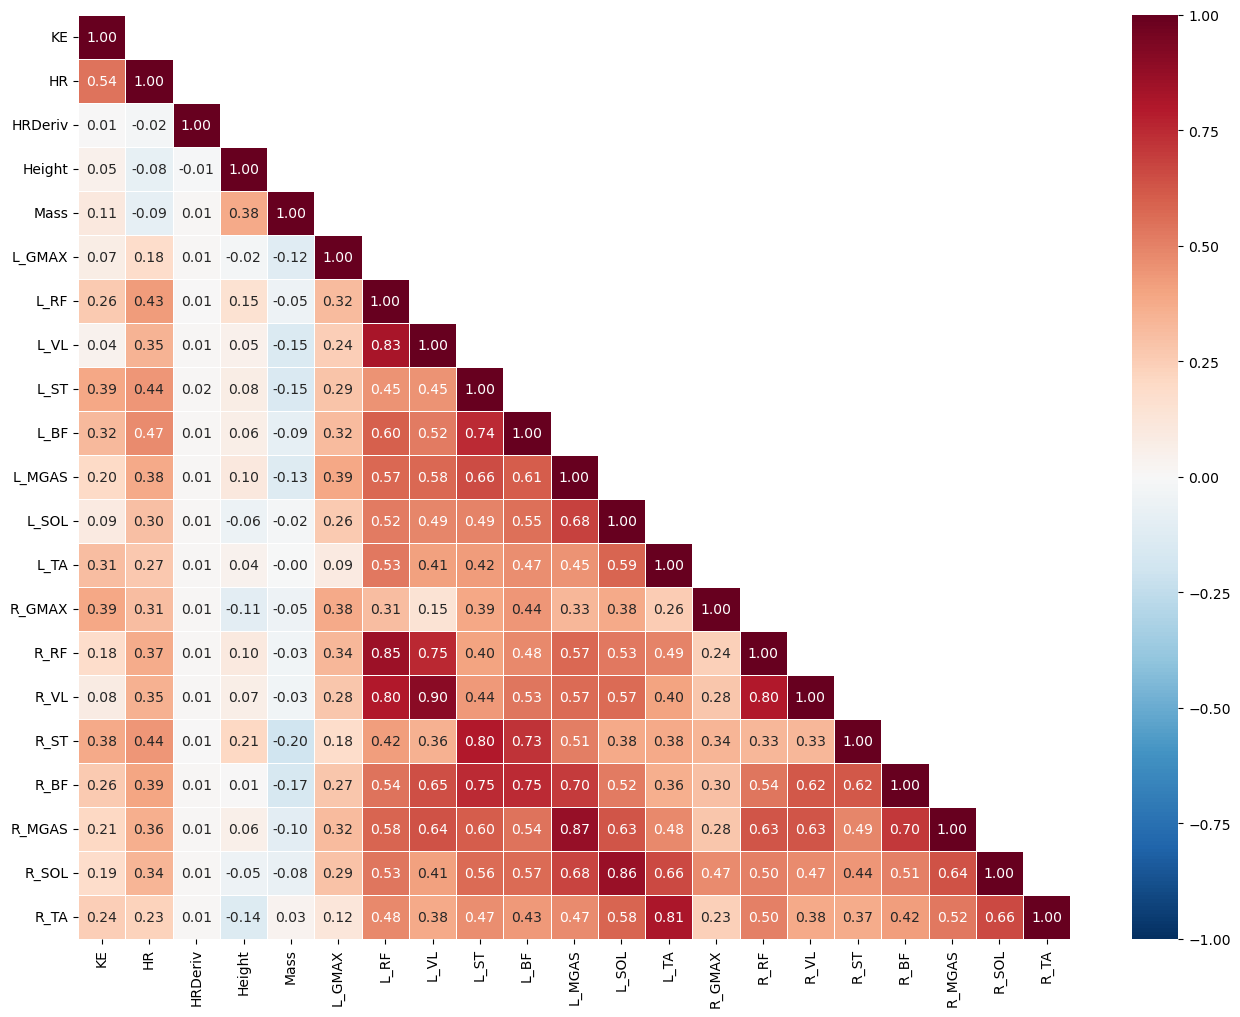

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
emg_map = {
    'EMG2':'R_GMAX',
    'EMG3':'R_RF',
    'EMG4':'R_VL',
    'EMG5':'R_ST',
    'EMG6':'R_BF',
    'EMG7':'R_MGAS',
    'EMG8':'R_SOL',
    'EMG9':'R_TA',
    
    'EMG10':'L_GMAX',
    'EMG11':'L_RF',
    'EMG12':'L_VL',
    'EMG13':'L_ST',
    'EMG14':'L_BF',
    'EMG15':'L_MGAS',
    'EMG16':'L_SOL',
    'EMG17':'L_TA',
    'Weight':'Mass',
}

merged_df = merged_df.rename(columns=emg_map)
# 1. Define your specific list (including the EMG range you requested)
want_cols = [
    'KE', 'HR', 'HRDeriv', 'Height', 'Mass',
    'L_GMAX', 'L_RF', 'L_VL', 'L_ST', 'L_BF', 'L_MGAS', 'L_SOL', 'L_TA',
    'R_GMAX', 'R_RF', 'R_VL', 'R_ST', 'R_BF', 'R_MGAS', 'R_SOL', 'R_TA'
]

# 2. Filter the dataframe to only include columns that actually exist in merged_df
# (This prevents errors if a specific EMG channel was missing)
available_cols = [col for col in want_cols if col in merged_df.columns]
df_for_corr = merged_df[available_cols]

# 3. Calculate the correlation matrix
corr_matrix = df_for_corr.corr()

# 4. Plotting
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
# We use 'RdBu_r' to match your original image style
# annot=True puts the numbers in the boxes
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.show()

In [16]:
# 1. Define the mapping of (Old Name : New Name)
column_mapping = {
    'Subject':'Subject',
    'EE':'EE',
    'KE': 'KE',
    'HR': 'HR',
    'HRDeriv': 'HRDeriv',
    'Weight': 'Weight',
    'L_BF': 'lbf',    # Assuming L_BF maps to dbf
    'L_SOL': 'lsol',
    'R_BF': 'rbf',
    'R_SOL': 'rsol'
}

# 2. Select the keys and rename them in one step
reduced_df = merged_df[list(column_mapping.keys())].rename(columns=column_mapping)

reduced_df.to_pickle('merged_df_train_v2.pkl')

print("File 'merged_df_train_v2.pkl' has been saved successfully.")

File 'merged_df_train_v2.pkl' has been saved successfully.


In [20]:
print(reduced_df)

        Subject      EE      KE       HR   HRDeriv  Weight     lbf    lsol  \
0     Subject01  1.3861  0.1312   4.2409  0.318053   63.49  0.0043  0.0113   
1     Subject01  1.3861  0.1456  11.4909  0.117781   63.49  0.0046  0.0098   
2     Subject01  1.3861  0.1390  12.8909 -0.298779   63.49  0.0036  0.0090   
3     Subject01  1.3861  0.1403  12.4909 -0.132147   63.49  0.0033  0.0086   
4     Subject01  1.3861  0.1289  11.4909 -0.309832   63.49  0.0028  0.0099   
...         ...     ...     ...      ...       ...     ...     ...     ...   
4768  Subject10  2.6765  0.7586  15.7892  0.263334   58.05  0.0049  0.0080   
4769  Subject10  2.6765  0.7754  18.5035  0.380530   58.05  0.0051  0.0092   
4770  Subject10  2.6765  0.7776  20.3607 -0.413233   58.05  0.0049  0.0093   
4771  Subject10  2.6765  0.7532  17.0273  0.253773   58.05  0.0051  0.0090   
4772  Subject10  2.6765  0.7905  19.5035  0.290154   58.05  0.0052  0.0090   

         rbf    rsol  
0     0.0051  0.0124  
1     0.0044  0.0